In [ ]:
import pandas as pd

splits = {
    'validation': 'simplification/validation-00000-of-00001.parquet',
    'test': 'simplification/test-00000-of-00001.parquet'
}

df_test = pd.read_parquet("https://huggingface.co/datasets/facebook/asset/resolve/main/" + splits["test"])


In [ ]:
def expand_data(df):
    new_rows = []
    df = df.rename(columns={'simplifications': 'simplification'})
    for _, row in df.iterrows():
        for s in row['simplification']:
            new_rows.append({'original': row['original'], 'simplification': s})
    return pd.DataFrame(new_rows)

df_train = expand_data(df_test)

In [ ]:
from datasets import Dataset
from transformers import BartTokenizer

tokenizer = BartTokenizer.from_pretrained("facebook/bart-large")
hf_dataset = Dataset.from_pandas(df_train[["original", "simplification"]])

def preprocess(example):
    input_text = example["original"]
    target_text = example["simplification"]

    model_inputs = tokenizer(input_text, max_length=128, truncation=True, padding="max_length")
    labels = tokenizer(target_text, max_length=128, truncation=True, padding="max_length")

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized_dataset = hf_dataset.map(preprocess, batched=False)

In [ ]:

from transformers import BartForConditionalGeneration, TrainingArguments, Trainer

model = BartForConditionalGeneration.from_pretrained("facebook/bart-large")

training_args = TrainingArguments(
    output_dir="./results_bart",
    per_device_train_batch_size=8,
    num_train_epochs=3,
    logging_dir="./logs_bart",
    logging_steps=10,
    save_strategy="no",
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset
)

'\nfrom transformers import BartForConditionalGeneration, TrainingArguments, Trainer\n\nmodel = BartForConditionalGeneration.from_pretrained("facebook/bart-large")\n\ntraining_args = TrainingArguments(\n    output_dir="./results_bart",\n    per_device_train_batch_size=8,\n    num_train_epochs=3,\n    logging_dir="./logs_bart",\n    logging_steps=10,\n    save_strategy="no",  # No guardar checkpoints intermedios\n    report_to="none"  # Desactivar el uso de wandb\n)\n\ntrainer = Trainer(\n    model=model,\n    args=training_args,\n    train_dataset=tokenized_dataset\n)\n'

In [ ]:
trainer.train()

In [ ]:
model.save_pretrained("./bart-finetuned-simplification")
tokenizer.save_pretrained("./bart-finetuned-simplification")

In [ ]:
from transformers import BartForConditionalGeneration, BartTokenizer

model_path = "/content/bart-finetuned-simplification"

model = BartForConditionalGeneration.from_pretrained(model_path)
tokenizer = BartTokenizer.from_pretrained(model_path)


In [ ]:

def generate_simplification(text):
    input_ids = tokenizer(text, return_tensors="pt", truncation=True, padding="max_length", max_length=128).input_ids
    input_ids = input_ids.to(model.device)
    output_ids = model.generate(input_ids, max_length=128, num_beams=4, early_stopping=True)
    return tokenizer.decode(output_ids[0], skip_special_tokens=True)

df_test["generated"] = df_test["original"].apply(generate_simplification)

In [ ]:
!git clone https://github.com/feralvam/easse.git
%cd easse
!pip install -e .

In [ ]:
from easse.sari import corpus_sari
from easse.bleu import sentence_bleu
from easse.fkgl import corpus_fkgl
import numpy as np
from tqdm.auto import tqdm
import nltk
nltk.download('punkt_tab')

df_eval = df_test.dropna(subset=["generated"]).reset_index(drop=True)

saris = []
bleus = []

for i in tqdm(range(len(df_eval))):
    sari_score = corpus_sari(
        orig_sents=[df_eval.loc[i, "original"]],
        sys_sents=[df_eval.loc[i, "generated"]],
        refs_sents=[[ref] for ref in df_eval.loc[i, "simplifications"]],
        use_paper_version=True
    )
    saris.append(sari_score)

    bleu_score = sentence_bleu(
        sys_sent=df_eval.loc[i, "generated"],
        ref_sents=df_eval.loc[i, "simplifications"]
    )
    bleus.append(bleu_score)

fkgl_score = corpus_fkgl(df_eval["generated"].tolist())

print(f"SARI (↑): {np.mean(saris):.3f}")
print(f"BLEU (↑): {np.mean(bleus):.3f}")
print(f"FKGL (↓): {fkgl_score:.3f}")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


  0%|          | 0/359 [00:00<?, ?it/s]

SARI (↑): 42.304
BLEU (↑): 97.072
FKGL (↓): 8.362


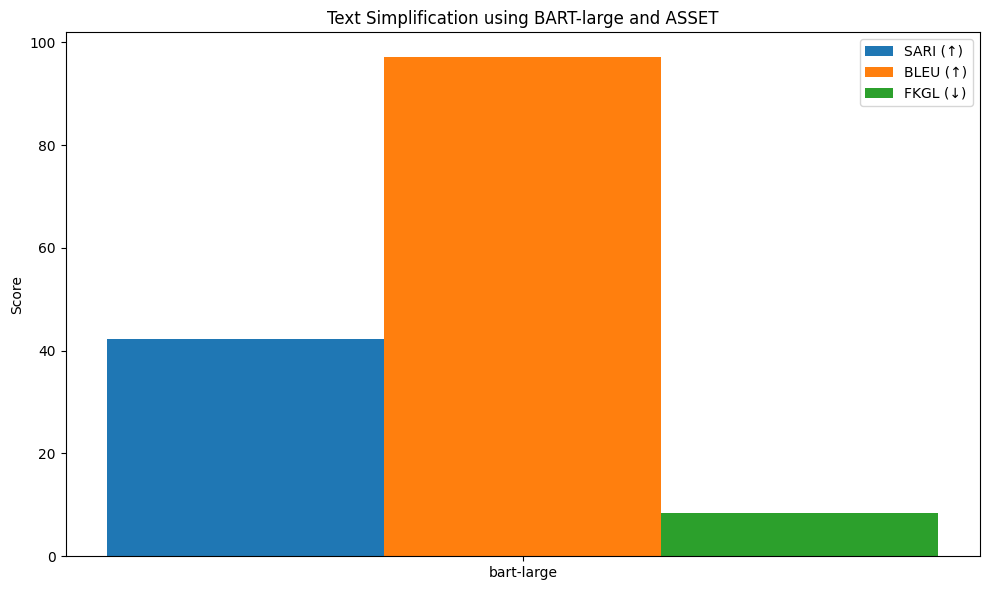

In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt

results_file = "/mnt/data/model_comparison_results.csv"

def save_model_result(model_name, sari, bleu, fkgl):
    if os.path.exists(results_file):
        df = pd.read_csv(results_file)
    else:
        df = pd.DataFrame(columns=["Model", "SARI", "BLEU", "FKGL"])
    df = df[df["Model"] != model_name]
    df.loc[len(df)] = [model_name, sari, bleu, fkgl]
    df.to_csv(results_file, index=False)
    return df

os.makedirs("/mnt/data", exist_ok=True)


df_updated = save_model_result(
    "bart-large",
    np.mean(saris),
    np.mean(bleus),
    fkgl_score
)


labels = df_updated['Model']
sari = df_updated['SARI']
bleu = df_updated['BLEU']
fkgl = df_updated['FKGL']

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width, sari, width, label='SARI (↑)')
ax.bar(x, bleu, width, label='BLEU (↑)')
ax.bar(x + width, fkgl, width, label='FKGL (↓)')

ax.set_ylabel('Score')
ax.set_title('Text Simplification using BART-large and ASSET')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
plt.tight_layout()
plt.show()